# Figure 2E

In [ ]:
### Load SRA metadata
#  import duckdb

# %load_ext sql
# conn = duckdb.connect()
# %sql conn --alias duckdb

In [ ]:
# %%sql
### Identify public Illumina shotgun metagenomes
# INSTALL httpfs;
# LOAD httpfs;
# INSTALL parquet;
# LOAD parquet;
# COPY (
#   SELECT 
#     acc, biosample, consent, releasedate,
#     bioproject, librarysource, libraryselection, librarylayout,
#     platform, instrument, organism, mbases, avgspotlen, assay_type
#   FROM read_parquet('s3://sra-pub-metadata-us-east-1/sra/metadata/*')
#   WHERE assay_type != 'AMPLICON'
#   AND consent = 'public'
#   AND platform = 'ILLUMINA'
#   AND librarylayout = 'PAIRED'
#   AND libraryselection != 'PCR'
#   AND (librarysource = 'METAGENOMIC'
#     OR organism LIKE '%microbiom%'
#     OR organism LIKE '%metagenom%')
# ) TO '2025_07_22_sra_metadata.parquet' (FORMAT 'parquet'); 

In [ ]:
# ### Identify gut, oral, skin, and urogenital metagenomes
# import polars as pl
# from datetime import datetime

# sra_metadata = pl.read_parquet('2025_07_22_sra_metadata.parquet')

# gut_samples = (
#     sra_metadata
#         .filter(
#             (
#                 (pl.col('organism').str.contains('gut metagenome')) |
#                 (pl.col('organism').str.contains('feces metagenome'))
#             )
#         )
#         .sort(pl.col('mbases'), descending=True)
#         .unique('biosample', maintain_order=True)
# )

# oral_samples = (
#     sra_metadata
#         .filter(
#             (
#                 (pl.col('organism').str.contains('oral')) |
#                 (pl.col('organism').str.contains('nasopharyngeal')) |
#                 (pl.col('organism').str.contains('lung')) |
#                 (pl.col('organism').str.contains('saliva')) |
#                 (pl.col('organism').str.contains('sputum')) |
#                 (pl.col('organism').str.contains('respiratory')) |
#                 (pl.col('organism').str.contains('airway'))
#             )
#         )
#         .sort(pl.col('mbases'), descending=True)
#         .unique('biosample', maintain_order=True)
# )

# skin_samples = (
#     sra_metadata
#         .filter(
#             (pl.col('organism').str.contains('skin'))
#         )
#         .sort(pl.col('mbases'), descending=True)
#         .unique('biosample', maintain_order=True)
# )

# urogenital_samples = (
#     sra_metadata
#         .filter(
#             (
#                 (pl.col('organism').str.contains('vaginal')) |
#                 (pl.col('organism').str.contains('urinary')) |
#                 (pl.col('organism').str.contains('semen'))
#             )
#         )
#         .sort(pl.col('mbases'), descending=True)
#         .unique('biosample', maintain_order=True)
# )

# print("Number of gut metagenomes:", gut_samples.shape[0])
# print("Number of oral metagenomes:", oral_samples.shape[0])
# print("Number of skin metagenomes:", skin_samples.shape[0])
# print("Number of urogenital metagenomes:", urogenital_samples.shape[0])

In [ ]:
# ### identify metagenomes added after mining cutoff date
# import polars as pl
# from datetime import datetime

# sra_metadata = pl.read_parquet('2025_07_22_sra_metadata.parquet')

# gut_samples = (
#     sra_metadata
#         .filter(
#             (pl.col('releasedate') > datetime(2025, 4, 30)) &
#             (
#                 (pl.col('organism').str.contains('human gut metagenome')) |
#                 (pl.col('organism').str.contains('human feces metagenome'))
#             ) &
#             (pl.col('mbases') > 1000) & (pl.col('mbases')<= 10000)
#         )
#         .sort(pl.col('mbases'), descending=True)
#         .unique('biosample', maintain_order=True)
# )

# oral_samples = (
#     sra_metadata
#         .filter(
#             (pl.col('releasedate') > datetime(2025, 4, 30)) &
#             (
#                 (pl.col('organism').str.contains('human oral metagenome')) |
#                 (pl.col('organism').str.contains('human nasopharyngeal metagenome')) |
#                 (pl.col('organism').str.contains('human lung metagenome')) |
#                 (pl.col('organism').str.contains('human saliva metagenome')) |
#                 (pl.col('organism').str.contains('human saliva')) |
#                 (pl.col('organism').str.contains('human sputum'))
#             ) &
#             (pl.col('mbases') > 1000) & (pl.col('mbases')<= 10000)
#         )
#         .sort(pl.col('mbases'), descending=True)
#         .unique('biosample', maintain_order=True)
# )

# skin_samples = (
#     sra_metadata
#         .filter(
#             (pl.col('organism').str.contains('human skin metagenome')) &
#             (pl.col('mbases') > 1000) & (pl.col('mbases')<= 10000)
#         )
#         .sort(pl.col('mbases'), descending=True)
#         .unique('biosample', maintain_order=True)
# )

# urogenital_samples = (
#     sra_metadata
#         .filter(
#             (
#                 (pl.col('organism').str.contains('human vaginal metagenome')) |
#                 (pl.col('organism').str.contains('human urinary tract metagenome')) |
#                 (pl.col('organism').str.contains('human semen metagenome'))
#             ) &
#             (pl.col('mbases') > 1000) & (pl.col('mbases')<= 10000)
#         )
#         .sort(pl.col('mbases'), descending=True)
#         .unique('biosample', maintain_order=True)
# )

In [ ]:
# ### identify studies with at least 10 samples
# gut_studies = gut_samples.group_by('bioproject').len().filter(pl.col('len') >= 10)
# gut_samples_filt = gut_samples.filter(pl.col('bioproject').is_in(gut_studies['bioproject']))

# oral_studies = oral_samples.group_by('bioproject').len().filter(pl.col('len') >= 10)
# oral_samples_filt = oral_samples.filter(pl.col('bioproject').is_in(oral_studies['bioproject']))

# skin_studies = skin_samples.group_by('bioproject').len().filter(pl.col('len') >= 10)
# skin_samples_filt = skin_samples.filter(pl.col('bioproject').is_in(skin_studies['bioproject']))

# urogenital_studies = urogenital_samples.group_by('bioproject').len().filter(pl.col('len') >= 10)
# urogenital_samples_filt = urogenital_samples.filter(pl.col('bioproject').is_in(urogenital_studies['bioproject']))

In [ ]:
# ### print number of samples and studies for each body site
# print(gut_studies.shape[0])
# print(gut_samples_filt.shape[0], "\n")

# print(oral_studies.shape[0])
# print(oral_samples_filt.shape[0], "\n")

# print(skin_studies.shape[0])
# print(skin_samples_filt.shape[0], "\n")

# print(urogenital_studies.shape[0])
# print(urogenital_samples_filt.shape[0], "\n")

In [ ]:
# ### Create samplesheets for each body site by evenly sampling from all studies
# gut_samples_final = (
#     gut_samples_filt
#         .group_by(pl.col('bioproject'))
#         .head(3)
#         .sample(100)
#         .with_columns([
#             pl.col('biosample').alias('group'),
#             pl.col('acc').alias('sample')
#         ])
#         .write_csv('gut_samplesheet.csv')
# )

# oral_samples_final = (
#     oral_samples_filt
#         .group_by(pl.col('bioproject'))
#         .head(19)
#         .sample(100)
#         .with_columns([
#             pl.col('biosample').alias('group'),
#             pl.col('acc').alias('sample')
#         ])
#         .write_csv('oral_samplesheet.csv')
# )

# skin_samples_final = (
#     skin_samples_filt
#         .group_by(pl.col('bioproject'))
#         .head(4)
#         .sample(100)
#         .with_columns([
#             pl.col('biosample').alias('group'),
#             pl.col('acc').alias('sample')
#         ])
#         .write_csv('skin_samplesheet.csv')
# )

# urogenital_samples_final = (
#     urogenital_samples_filt
#         .group_by(pl.col('bioproject'))
#         .head(6)
#         .sample(100)
#         .with_columns([
#             pl.col('biosample').alias('group'),
#             pl.col('acc').alias('sample')
#         ])
#         .write_csv('urogenital_samplesheet.csv')
# )

In [ ]:
### Prepare fasta file for alignments ###
import polars as pl
import os

# # load samplesheets
# gut_samplesheet = pl.read_csv('gut_samplesheet.csv').with_columns([pl.lit('gut').alias('body_site')])
# oral_samplesheet = pl.read_csv('oral_samplesheet.csv').with_columns([pl.lit('oral').alias('body_site')])
# skin_samplesheet = pl.read_csv('skin_samplesheet.csv').with_columns([pl.lit('skin').alias('body_site')])
# urogenital_samplesheet = pl.read_csv('urogenital_samplesheet.csv').with_columns([pl.lit('urogenital').alias('body_site')])
# combined_samplesheet = pl.concat([gut_samplesheet, oral_samplesheet, skin_samplesheet, urogenital_samplesheet])

# for row in combined_samplesheet.iter_rows(named=True):
#     bioproject = row['bioproject'].lower()
#     virus_fasta = f"/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/comprehensivity_analysis/results/uhvdb/assemble/{bioproject}/{row['biosample']}/{row['acc']}/uhvdb/virusfilter/{row['acc']}.uhvdb_viruses.fna.gz"
#     renamed_virus_fasta = f"/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/comprehensivity_analysis/results/uhvdb/assemble/{bioproject}/{row['biosample']}/{row['acc']}/uhvdb/virusfilter/{row['acc']}.renamed.fna.gz"

#     if os.path.exists(virus_fasta):
#         if os.path.exists(renamed_virus_fasta):
#             continue
#         else:
#             # add prefix to fasta sequence IDs
#             !seqkit replace \
#                 {virus_fasta} \
#                 --pattern "^" \
#                 --replacement {row['acc']}_ | \
#             seqkit rename \
#                 --out-file {renamed_virus_fasta}
#     else:
#         print("No virus fasta found for", row['acc'])
#         continue

In [ ]:
%%bash
### Alignment to UHGV ###
# create UHGV HQ vOTU reps database
# !micromamba run -n blast makeblastdb \
#         -in votus_hq_plus.fna \
#         -dbtype nucl \
#         -out votus_hq_plus_blastdb

# # combine sequences from all samples
# seqkit concat \
#     results/uhvdb/assemble/*/*/*/uhvdb/virusfilter/*.renamed.fna.gz \
#     --full \
#     --out-file combined_renamed.fna

# # split sequences into smaller files for parallelization
# seqkit split combined_renamed.fna --by-part 16 --out-dir combined_renamed
# mkdir -p uhgv_blast


# # align sequences to UHGV HQ vOTU reps
# micromamba run -n blast ls combined_renamed | parallel "
#     blastn \
#     -query combined_renamed/{} \
#     -db votus_hq_plus_blastdb \
#     -outfmt '6  std qlen slen' \
#     -max_target_seqs 1000 \
#     -out uhgv_blast/{} \
#     -num_threads 1
# "

# cat uhgv_blast/* > uhgv.blastn.tsv

# micromamba run -n blast python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/assembler_benchmark/composite_sputum/anicalc.py \
#     -i uhgv.blastn.tsv \
#     -o uhgv.anicalc.tsv

In [ ]:
%%bash
### Alignment to UHVDB ###
# gunzip -c \
#     /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_clustering/uhvdb.votu_reps.fna.gz \
#     > uhvdb.vclust_reps.fna

# # create UHVDB HQ vOTU reps database
# mkdir -p uhvdb_blast
# micromamba run -n blast makeblastdb \
#         -in uhvdb.vclust_reps.fna \
#         -dbtype nucl \
#         -out uhvdb_blast/uhvdb.vclust_reps_blastdb

# # align sequences to UHVDB HQ vOTU reps
# ls /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/comprehensivity_analysis/combined_renamed | parallel "
#     blastn \
#     -query /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/comprehensivity_analysis/combined_renamed/{} \
#     -db uhvdb_blast/uhvdb.vclust_reps_blastdb \
#     -outfmt '6  std qlen slen' \
#     -max_target_seqs 1000 \
#     -out uhvdb_blast/{} \
#     -num_threads 2
# "

# cat uhvdb_blast/*.fna > uhvdb.blastn.tsv

# micromamba run -n blast python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/assembler_benchmark/composite_sputum/anicalc.py \
#     -i uhvdb.blastn.tsv \
#     -o uhvdb.anicalc.tsv

In [ ]:
### IMG/VR HQ preparation ###
# metadata downloaded from:
# https://genome.jgi.doe.gov/portal/pages/dynamicOrganismDownload.jsf?organism=IMG_VR#

# import polars as pl

# imgvr_meta = pl.read_csv('IMGVR_all_Sequence_information.tsv', separator='\t',
#     columns=['UVIG', 'Topology', 'Confidence', 'Estimated completeness', 'vOTU', 'Length'])

# imgvr_meta_filt = (
#     imgvr_meta
#         .with_columns([
#             pl.col('Estimated completeness').replace('NA', None).cast(pl.Float64),
#         ])
#         .filter(
#             pl.col('Estimated completeness') >= 90
#         )
#         .sort(pl.col('Length'), descending=True)
#         .group_by(pl.col('vOTU'), maintain_order=True)
#         .first()
# )
# imgvr_meta_filt[['UVIG']].write_csv('imgvr_hq_viruses.tsv')

# !wget https://portal.nersc.gov/genomad/__data__/IMGVR_DATA/IMGVR4_SEQUENCES.fna

# !seqkit grep \
#     --pattern-file imgvr_hq_viruses.tsv IMGVR4_SEQUENCES.fna \
#     --id-regexp "^(.*?)\|" \
#     -j 4 \
#     --out-file IMGVR4_hq_sequences.fna

In [ ]:
%%bash
### Alignment to IMGVR ###
# # create IMG/VR HQ vOTU reps database
# micromamba run -n blast makeblastdb \
#         -in IMGVR4_hq_sequences.fna \
#         -dbtype nucl \
#         -out imgvr_hq_votu_reps_blastdb

# # align sequences to UHVDB HQ vOTU reps
# mkdir -p imgvr_blast
# micromamba run -n blast ls combined_renamed | parallel "
#     blastn \
#     -query combined_renamed/{} \
#     -db imgvr_hq_votu_reps_blastdb \
#     -outfmt '6  std qlen slen' \
#     -max_target_seqs 1000 \
#     -out imgvr_blast/{} \
#     -num_threads 1
# "

# cat imgvr_blast/* > imgvr.blastn.tsv

# micromamba run -n blast python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/assembler_benchmark/composite_sputum/anicalc.py \
#     -i imgvr.blastn.tsv \
#     -o imgvr.anicalc.tsv

In [ ]:
%%bash
### Alignment to INPHARED ###
#!wget https://millardlab-inphared.s3.climb.ac.uk/14Apr2025_genomes.fa.gz

### Dereplicate sequences with vclust ###
# micromamba run -n vclust \
# vclust \
#     deduplicate \
#     --in 14Apr2025_genomes.fa.gz \
#     --out 14Apr2025_genomes.vclust_deduplicate.fna.gz \
#     --gzip-output \
#     --threads 16

# # micromamba run -n vclust \
# vclust \
#     prefilter \
#     --in 14Apr2025_genomes.vclust_deduplicate.fna.gz \
#     --out 14Apr2025_genomes.vclust_prefilter.txt \
#     --threads 16 \
#     --min-ident 0.95 \
#     --kmers-fraction 0.2

# # micromamba run -n vclust \
# vclust \
#     align \
#     --in 14Apr2025_genomes.vclust_deduplicate.fna.gz \
#     --out 14Apr2025_genomes.vclust_ani.tsv \
#     --filter 14Apr2025_genomes.vclust_prefilter.txt \
#     --threads 16 \
#     --out-ani 0.95 \
#     --out-qcov 0.85

# # micromamba run -n vclust \
# vclust \
#     cluster \
#     --in 14Apr2025_genomes.vclust_ani.tsv \
#     --ids 14Apr2025_genomes.vclust_ani.ids.tsv \
#     --out 14Apr2025_genomes.vclust_clusters.tsv \
#     --algorithm cd-hit \
#     --metric ani \
#     --ani 0.95 \
#     --qcov 0.85 \
#     --out-repr

# csvtk \
#     cut \
#     14Apr2025_genomes.vclust_clusters.tsv \
#     --tabs \
#     --fields cluster | \
# csvtk \
#     uniq \
#     --tabs \
#     --out-file 14Apr2025_genomes.vclust_reps.tsv

# seqkit \
#     grep \
#     14Apr2025_genomes.vclust_deduplicate.fna.gz \
#     --pattern-file 14Apr2025_genomes.vclust_reps.tsv \
#     --threads 16 \
#     --out-file 14Apr2025_genomes.vclust_reps.fna

### Align sequences to inphared reps with BLASTn ###
# # create IMG/VR HQ vOTU reps database
# micromamba run -n blast makeblastdb \
#         -in 14Apr2025_genomes.vclust_reps.fna \
#         -dbtype nucl \
#         -out inphared_votu_reps_blastdb

# # align sequences to inphared HQ vOTU reps
# mkdir -p inphared_blast
# micromamba run -n blast ls combined_renamed | parallel "
#     blastn \
#     -query combined_renamed/{} \
#     -db inphared_votu_reps_blastdb \
#     -outfmt '6  std qlen slen' \
#     -max_target_seqs 1000 \
#     -out inphared_blast/{} \
#     -num_threads 1
# "

# cat inphared_blast/* > inphared.blastn.tsv

# micromamba run -n blast python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/assembler_benchmark/composite_sputum/anicalc.py \
#     -i inphared.blastn.tsv \
#     -o inphared.anicalc.tsv

In [21]:
### Determine proportion aligning to UHGV at species level ###
import polars as pl

# load samplesheets
gut_samplesheet = pl.read_csv('gut_samplesheet.csv').with_columns([pl.lit('gut').alias('body_site')])
oral_samplesheet = pl.read_csv('oral_samplesheet.csv').with_columns([pl.lit('airways').alias('body_site')])
skin_samplesheet = pl.read_csv('skin_samplesheet.csv').with_columns([pl.lit('skin').alias('body_site')])
urogenital_samplesheet = pl.read_csv('urogenital_samplesheet.csv').with_columns([pl.lit('urogenital').alias('body_site')])
combined_samplesheet = pl.concat([gut_samplesheet, oral_samplesheet, skin_samplesheet, urogenital_samplesheet])

# !grep "^>" combined_renamed.fna > combined_renamed.fna.ids

seq2site = (
    pl.read_csv('combined_renamed.fna.ids', has_header=False)
        .rename({'column_1': 'qname'})
        .with_columns([
            pl.col('qname').str.split('_k').list[0].str.replace('>', '').alias('acc'),
            pl.col('qname').str.replace('>', '').str.split(' ').list[0]
        ])
        .join(combined_samplesheet, on='acc', how='inner')
)

# determine proportion of viruses aligned to UHGV at species level (95% ID and 85% AF)
uhgv_anicalc = pl.read_csv('uhgv.anicalc.tsv', separator='\t')

uhgv_species_aligned = (
    uhgv_anicalc
        .filter(
            (pl.col('pid') >= 95) &
            ( (pl.col('qcov') >= 85) | (pl.col('tcov') >= 85) )
        )
        .join(seq2site, on='qname', how='full', coalesce=True)
        .unique('qname')
)
total_gut_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'gut')).shape[0]
aligned_hq_gut_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'gut') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ gut viruses assembled:", total_gut_viruses)
print("Number of HQ gut viruses aligned to UHGV at species level:", aligned_hq_gut_viruses)
print("Proportion of HQ gut viruses aligned to UHGV at species level:", aligned_hq_gut_viruses / total_gut_viruses, "\n")

total_oral_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'airways')).shape[0]
aligned_hq_oral_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'airways') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ oral viruses assembled:", total_oral_viruses)
print("Number of HQ oral viruses aligned to UHGV at species level:", aligned_hq_oral_viruses)
print("Proportion of HQ oral viruses aligned to UHGV at species level:", aligned_hq_oral_viruses / total_oral_viruses, "\n")

total_skin_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'skin')).shape[0]
aligned_hq_skin_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'skin') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ skin viruses assembled:", total_skin_viruses)
print("Number of HQ skin viruses aligned to UHGV at species level:", aligned_hq_skin_viruses)
print("Proportion of HQ skin viruses aligned to UHGV at species level:", aligned_hq_skin_viruses / total_skin_viruses, "\n")

total_urogenital_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'urogenital')).shape[0]
aligned_hq_urogenital_viruses = uhgv_species_aligned.filter((pl.col('body_site') == 'urogenital') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ urogenital viruses assembled:", total_urogenital_viruses)
print("Number of HQ urogenital viruses aligned to UHGV at species level:", aligned_hq_urogenital_viruses)
print("Proportion of HQ urogenital viruses aligned to UHGV at species level:", aligned_hq_urogenital_viruses / total_urogenital_viruses, "\n")

Number of HQ gut viruses assembled: 1022
Number of HQ gut viruses aligned to UHGV at species level: 545
Proportion of HQ gut viruses aligned to UHGV at species level: 0.5332681017612525 

Number of HQ oral viruses assembled: 437
Number of HQ oral viruses aligned to UHGV at species level: 56
Proportion of HQ oral viruses aligned to UHGV at species level: 0.12814645308924486 

Number of HQ skin viruses assembled: 222
Number of HQ skin viruses aligned to UHGV at species level: 32
Proportion of HQ skin viruses aligned to UHGV at species level: 0.14414414414414414 

Number of HQ urogenital viruses assembled: 136
Number of HQ urogenital viruses aligned to UHGV at species level: 39
Proportion of HQ urogenital viruses aligned to UHGV at species level: 0.2867647058823529 



In [22]:
### Determine proportion aligning to UHVDB at species level ###
seq2site = (
    pl.read_csv('combined_renamed.fna.ids', has_header=False)
        .rename({'column_1': 'qname'})
        .with_columns([
            pl.col('qname').str.split('_k').list[0].str.replace('>', '').alias('acc'),
            pl.col('qname').str.replace('>', '').str.split(' ').list[0]
        ])
        .join(combined_samplesheet, on='acc', how='inner')
)

# determine proportion of viruses aligned to UHVDB at species level (95% ID and 85% AF)
uhvdb_anicalc = pl.read_csv('uhvdb.anicalc.tsv', separator='\t')

uhvdb_species_aligned = (
    uhvdb_anicalc
        .filter(
            (pl.col('pid') >= 95) &
            ( (pl.col('qcov') >= 85) | (pl.col('tcov') >= 85) )
        )
        .join(seq2site, on='qname', how='full', coalesce=True)
        .unique('qname')
)
total_gut_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'gut')).shape[0]
aligned_hq_gut_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'gut') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ gut viruses assembled:", total_gut_viruses)
print("Number of HQ gut viruses aligned to UHVDB at species level:", aligned_hq_gut_viruses)
print("Proportion of HQ gut viruses aligned to UHVDB at species level:", aligned_hq_gut_viruses / total_gut_viruses, "\n")

total_oral_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'airways')).shape[0]
aligned_hq_oral_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'airways') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ oral viruses assembled:", total_oral_viruses)
print("Number of HQ oral viruses aligned to UHVDB at species level:", aligned_hq_oral_viruses)
print("Proportion of HQ oral viruses aligned to UHVDB at species level:", aligned_hq_oral_viruses / total_oral_viruses, "\n")

total_skin_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'skin')).shape[0]
aligned_hq_skin_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'skin') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ skin viruses assembled:", total_skin_viruses)
print("Number of HQ skin viruses aligned to UHVDB at species level:", aligned_hq_skin_viruses)
print("Proportion of HQ skin viruses aligned to UHVDB at species level:", aligned_hq_skin_viruses / total_skin_viruses, "\n")

total_urogenital_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'urogenital')).shape[0]
aligned_hq_urogenital_viruses = uhvdb_species_aligned.filter((pl.col('body_site') == 'urogenital') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ urogenital viruses assembled:", total_urogenital_viruses)
print("Number of HQ urogenital viruses aligned to UHVDB at species level:", aligned_hq_urogenital_viruses)
print("Proportion of HQ urogenital viruses aligned to UHVDB at species level:", aligned_hq_urogenital_viruses / total_urogenital_viruses, "\n")

Number of HQ gut viruses assembled: 1022
Number of HQ gut viruses aligned to UHVDB at species level: 549
Proportion of HQ gut viruses aligned to UHVDB at species level: 0.5371819960861057 

Number of HQ oral viruses assembled: 437
Number of HQ oral viruses aligned to UHVDB at species level: 147
Proportion of HQ oral viruses aligned to UHVDB at species level: 0.33638443935926776 

Number of HQ skin viruses assembled: 222
Number of HQ skin viruses aligned to UHVDB at species level: 142
Proportion of HQ skin viruses aligned to UHVDB at species level: 0.6396396396396397 

Number of HQ urogenital viruses assembled: 136
Number of HQ urogenital viruses aligned to UHVDB at species level: 89
Proportion of HQ urogenital viruses aligned to UHVDB at species level: 0.6544117647058824 



In [23]:
### Determine proportion aligning to imgvr at species level ###
seq2site = (
    pl.read_csv('combined_renamed.fna.ids', has_header=False)
        .rename({'column_1': 'qname'})
        .with_columns([
            pl.col('qname').str.split('_k').list[0].str.replace('>', '').alias('acc'),
            pl.col('qname').str.replace('>', '').str.split(' ').list[0]
        ])
        .join(combined_samplesheet, on='acc', how='inner')
)

# determine proportion of viruses aligned to imgvr at species level (95% ID and 85% AF)
imgvr_anicalc = pl.read_csv('imgvr.anicalc.tsv', separator='\t')

imgvr_species_aligned = (
    imgvr_anicalc
        .filter(
            (pl.col('pid') >= 95) &
            ( (pl.col('qcov') >= 85) | (pl.col('tcov') >= 85) )
        )
        .join(seq2site, on='qname', how='full', coalesce=True)
        .unique('qname')
)
total_gut_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'gut')).shape[0]
aligned_hq_gut_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'gut') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ gut viruses assembled:", total_gut_viruses)
print("Number of HQ gut viruses aligned to imgvr at species level:", aligned_hq_gut_viruses)
print("Proportion of HQ gut viruses aligned to imgvr at species level:", aligned_hq_gut_viruses / total_gut_viruses, "\n")

total_oral_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'airways')).shape[0]
aligned_hq_oral_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'airways') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ oral viruses assembled:", total_oral_viruses)
print("Number of HQ oral viruses aligned to imgvr at species level:", aligned_hq_oral_viruses)
print("Proportion of HQ oral viruses aligned to imgvr at species level:", aligned_hq_oral_viruses / total_oral_viruses, "\n")

total_skin_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'skin')).shape[0]
aligned_hq_skin_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'skin') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ skin viruses assembled:", total_skin_viruses)
print("Number of HQ skin viruses aligned to imgvr at species level:", aligned_hq_skin_viruses)
print("Proportion of HQ skin viruses aligned to imgvr at species level:", aligned_hq_skin_viruses / total_skin_viruses, "\n")

total_urogenital_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'urogenital')).shape[0]
aligned_hq_urogenital_viruses = imgvr_species_aligned.filter((pl.col('body_site') == 'urogenital') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ urogenital viruses assembled:", total_urogenital_viruses)
print("Number of HQ urogenital viruses aligned to imgvr at species level:", aligned_hq_urogenital_viruses)
print("Proportion of HQ urogenital viruses aligned to imgvr at species level:", aligned_hq_urogenital_viruses / total_urogenital_viruses, "\n")

Number of HQ gut viruses assembled: 1022
Number of HQ gut viruses aligned to imgvr at species level: 612
Proportion of HQ gut viruses aligned to imgvr at species level: 0.598825831702544 

Number of HQ oral viruses assembled: 437
Number of HQ oral viruses aligned to imgvr at species level: 92
Proportion of HQ oral viruses aligned to imgvr at species level: 0.21052631578947367 

Number of HQ skin viruses assembled: 222
Number of HQ skin viruses aligned to imgvr at species level: 68
Proportion of HQ skin viruses aligned to imgvr at species level: 0.3063063063063063 

Number of HQ urogenital viruses assembled: 136
Number of HQ urogenital viruses aligned to imgvr at species level: 46
Proportion of HQ urogenital viruses aligned to imgvr at species level: 0.3382352941176471 



In [24]:
### Determine proportion aligning to inphared at species level ###
seq2site = (
    pl.read_csv('combined_renamed.fna.ids', has_header=False)
        .rename({'column_1': 'qname'})
        .with_columns([
            pl.col('qname').str.split('_k').list[0].str.replace('>', '').alias('acc'),
            pl.col('qname').str.replace('>', '').str.split(' ').list[0]
        ])
        .join(combined_samplesheet, on='acc', how='inner')
)

# determine proportion of viruses aligned to inphared at species level (95% ID and 85% AF)
inphared_anicalc = pl.read_csv('inphared.anicalc.tsv', separator='\t')

inphared_species_aligned = (
    inphared_anicalc
        .filter(
            (pl.col('pid') >= 95) &
            ( (pl.col('qcov') >= 85) | (pl.col('tcov') >= 85) )
        )
        .join(seq2site, on='qname', how='full', coalesce=True)
        .unique('qname')
)
total_gut_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'gut')).shape[0]
aligned_hq_gut_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'gut') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ gut viruses assembled:", total_gut_viruses)
print("Number of HQ gut viruses aligned to inphared at species level:", aligned_hq_gut_viruses)
print("Proportion of HQ gut viruses aligned to inphared at species level:", aligned_hq_gut_viruses / total_gut_viruses, "\n")

total_oral_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'airways')).shape[0]
aligned_hq_oral_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'airways') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ oral viruses assembled:", total_oral_viruses)
print("Number of HQ oral viruses aligned to inphared at species level:", aligned_hq_oral_viruses)
print("Proportion of HQ oral viruses aligned to inphared at species level:", aligned_hq_oral_viruses / total_oral_viruses, "\n")

total_skin_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'skin')).shape[0]
aligned_hq_skin_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'skin') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ skin viruses assembled:", total_skin_viruses)
print("Number of HQ skin viruses aligned to inphared at species level:", aligned_hq_skin_viruses)
print("Proportion of HQ skin viruses aligned to inphared at species level:", aligned_hq_skin_viruses / total_skin_viruses, "\n")

total_urogenital_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'urogenital')).shape[0]
aligned_hq_urogenital_viruses = inphared_species_aligned.filter((pl.col('body_site') == 'urogenital') & (pl.col('tname').is_not_null())).shape[0]
print("Number of HQ urogenital viruses assembled:", total_urogenital_viruses)
print("Number of HQ urogenital viruses aligned to inphared at species level:", aligned_hq_urogenital_viruses)
print("Proportion of HQ urogenital viruses aligned to inphared at species level:", aligned_hq_urogenital_viruses / total_urogenital_viruses, "\n")

Number of HQ gut viruses assembled: 1022
Number of HQ gut viruses aligned to inphared at species level: 72
Proportion of HQ gut viruses aligned to inphared at species level: 0.07045009784735812 

Number of HQ oral viruses assembled: 437
Number of HQ oral viruses aligned to inphared at species level: 5
Proportion of HQ oral viruses aligned to inphared at species level: 0.011441647597254004 

Number of HQ skin viruses assembled: 222
Number of HQ skin viruses aligned to inphared at species level: 5
Proportion of HQ skin viruses aligned to inphared at species level: 0.02252252252252252 

Number of HQ urogenital viruses assembled: 136
Number of HQ urogenital viruses aligned to inphared at species level: 18
Proportion of HQ urogenital viruses aligned to inphared at species level: 0.1323529411764706 



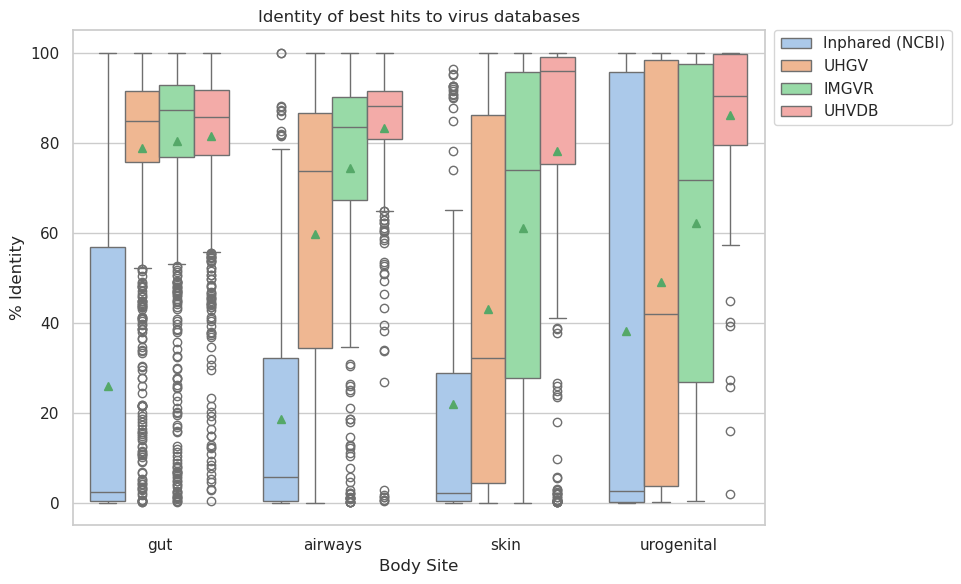

In [27]:
### Calculate global ANI of each assembled virus to the best hit in each database ###
uhgv_best_hit = (
    uhgv_anicalc
        .with_columns([
            (pl.col('pid') * pl.col('qcov') / 100).alias('qani'),
        ])
        .sort('qani', descending=True)
        .group_by('qname', maintain_order=True)
        .first()
        .join(seq2site, on='qname', how='full', coalesce=True)
        .with_columns([
            pl.lit('UHGV').alias('Database')
        ])
)

uhvdb_best_hit = (
    uhvdb_anicalc
        .with_columns([
            (pl.col('pid') * pl.col('qcov') / 100).alias('qani'),
        ])
        .sort('qani', descending=True)
        .group_by('qname', maintain_order=True)
        .first()
        .join(seq2site, on='qname', how='full', coalesce=True)
        .with_columns([
            pl.lit('UHVDB').alias('Database')
        ])
)

imgvr_best_hit = (
    imgvr_anicalc
        .with_columns([
            (pl.col('pid') * pl.col('qcov') / 100).alias('qani'),
        ])
        .sort('qani', descending=True)
        .group_by('qname', maintain_order=True)
        .first()
        .join(seq2site, on='qname', how='full', coalesce=True)
        .with_columns([
            pl.lit('IMGVR').alias('Database')
        ])
)

inphared_best_hit = (
    inphared_anicalc
        .with_columns([
            (pl.col('pid') * pl.col('qcov') / 100).alias('qani'),
        ])
        .sort('qani', descending=True)
        .group_by('qname', maintain_order=True)
        .first()
        .join(seq2site, on='qname', how='full', coalesce=True)
        .with_columns([
            pl.lit('Inphared').alias('Database')
        ])
)

best_hits = pl.concat([inphared_best_hit, uhgv_best_hit, imgvr_best_hit, uhvdb_best_hit])

best_hits = best_hits.with_columns(pl.col('Database').str.replace('Inphared', 'Inphared (NCBI)'))

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='body_site', y='qani', hue='Database', palette='pastel', data=best_hits, showmeans=True, order=['gut', 'airways', 'skin', 'urogenital'])
plt.title('Identity of best hits to virus databases')
plt.xlabel('Body Site')
plt.ylabel('% Identity')
plt.legend(bbox_to_anchor=(1.27, 1), loc='upper right', borderaxespad=0)
plt.tight_layout()

In [15]:
# print mean identity values for each body site and database
for body_site in ['gut', 'airways', 'skin', 'urogenital']:
    for database in ['UHGV', 'UHVDB', 'IMGVR', 'Inphared']:
        mean_id = best_hits.filter(
            (pl.col('body_site') == body_site) &
            (pl.col('Database') == database)
        ).select(pl.col('qani').mean()).item()
        print(f"Mean % identity for {body_site} samples to {database}: {mean_id}")

Mean % identity for gut samples to UHGV: 78.80189358617234
Mean % identity for gut samples to UHVDB: 81.51242202657482
Mean % identity for gut samples to IMGVR: 80.39837032440475
Mean % identity for gut samples to Inphared: 25.98362488149351
Mean % identity for airways samples to UHGV: 59.79856638902149
Mean % identity for airways samples to UHVDB: 83.18905427649771
Mean % identity for airways samples to IMGVR: 74.2990090825688
Mean % identity for airways samples to Inphared: 18.718252380281694
Mean % identity for skin samples to UHGV: 43.1591764973262
Mean % identity for skin samples to UHVDB: 78.21846235321102
Mean % identity for skin samples to IMGVR: 61.053789050691236
Mean % identity for skin samples to Inphared: 21.942257923913044
Mean % identity for urogenital samples to UHGV: 49.121332504132226
Mean % identity for urogenital samples to UHVDB: 86.15206695522389
Mean % identity for urogenital samples to IMGVR: 62.094327635658914
Mean % identity for urogenital samples to Inphared:

In [ ]:
# IMG/VR has 255,910 vOTU reps
# UHVDB has 201,946 vOTU reps

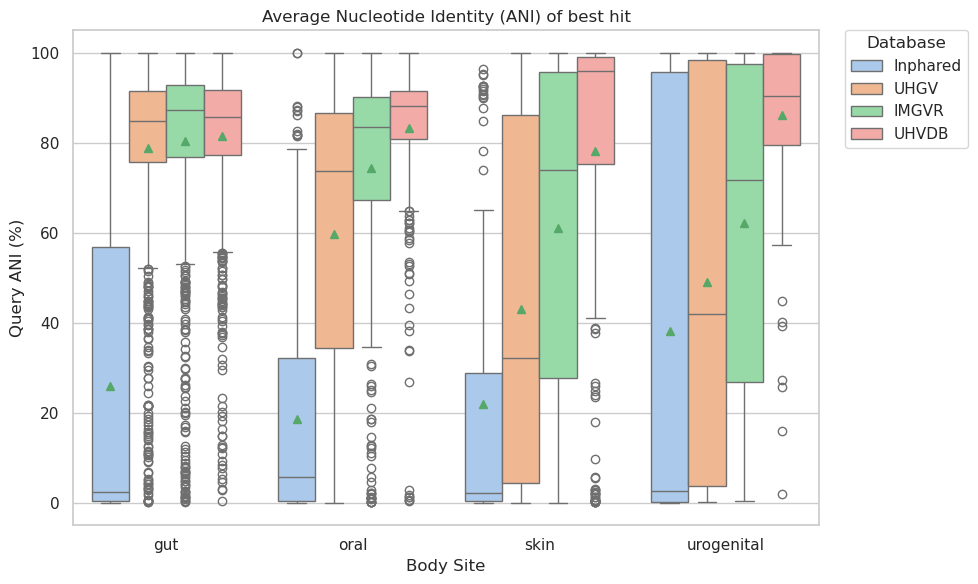

In [ ]:
### Plot ANI of best hit to each database ###
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(x='body_site', y='qani', hue='Database', palette='pastel', data=best_hits, showmeans=True, order=['gut', 'oral', 'skin', 'urogenital'])
plt.title('Average Nucleotide Identity (ANI) of best hit')
plt.xlabel('Body Site')
plt.ylabel('Query ANI (%)')
plt.legend(bbox_to_anchor=(1.2, 1), loc='upper right', borderaxespad=0, title='Database')
plt.tight_layout()

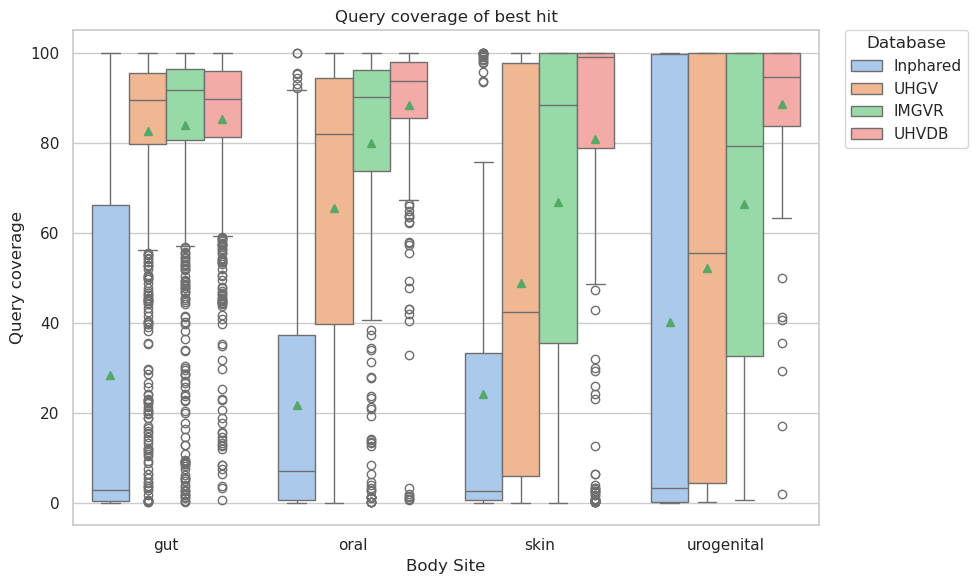

In [ ]:
### Plot query coverage of best hit to each database ###
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(x='body_site', y='qcov', hue='Database', palette='pastel', data=best_hits, showmeans=True, order=['gut', 'oral', 'skin', 'urogenital'])
plt.title('Query coverage of best hit')
plt.xlabel('Body Site')
plt.ylabel('Query coverage')
plt.legend(bbox_to_anchor=(1.2, 1), loc='upper right', borderaxespad=0, title='Database')
plt.tight_layout()